### Quais são as quantidades totais de vendas para cada categoria de medicamento (código ATC)?

In [242]:
import pandas as pd
import matplotlib.pyplot as plt

In [243]:
df = pd.read_csv("data/salesdaily.csv", parse_dates=["datum"])
df

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,2014-01-02,0.00,3.670,3.40,32.40,7.0,0.0,0.0,2.00,2014,1,248,Thursday
1,2014-01-03,8.00,4.000,4.40,50.60,16.0,0.0,20.0,4.00,2014,1,276,Friday
2,2014-01-04,2.00,1.000,6.50,61.85,10.0,0.0,9.0,1.00,2014,1,276,Saturday
3,2014-01-05,4.00,3.000,7.00,41.10,8.0,0.0,3.0,0.00,2014,1,276,Sunday
4,2014-01-06,5.00,1.000,4.50,21.70,16.0,2.0,6.0,2.00,2014,1,276,Monday
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2101,2019-10-04,7.34,5.683,2.25,22.45,13.0,0.0,1.0,1.00,2019,10,276,Friday
2102,2019-10-05,3.84,5.010,6.00,25.40,7.0,0.0,0.0,0.33,2019,10,276,Saturday
2103,2019-10-06,4.00,11.690,2.00,34.60,6.0,0.0,5.0,4.20,2019,10,276,Sunday
2104,2019-10-07,7.34,4.507,3.00,50.80,6.0,0.0,10.0,1.00,2019,10,276,Monday


In [244]:
categorias_atc = ["M01AB", "M01AE", "N02BA", "N02BE", "N05B", "N05C", "R03", "R06"]

totais = df[categorias_atc].sum().sort_values(ascending=False)

totais

N02BE    63005.402708
N05B     18645.737500
R03      11608.822917
M01AB    10600.937083
M01AE     8204.618646
N02BA     8172.209000
R06       6107.817500
N05C      1249.958333
dtype: float64

In [245]:
resultado = totais.reset_index()
resultado.columns = ["Codigo ATC", "Total de vendas"]

resultado["Participacao (%)"] = resultado["Total de vendas"] / resultado["Total de vendas"].sum() * 100

resultado["Total de vendas"] = resultado["Total de vendas"].map("{:,.2f}".format)
resultado["Participacao (%)"] = resultado["Participacao (%)"].map("{:.2f}%".format)

resultado

,Codigo ATC,Total de vendas,Participacao (%)
0,N02BE,"63,005.40",49.38%
1,N05B,"18,645.74",14.61%
2,R03,"11,608.82",9.10%
3,M01AB,"10,600.94",8.31%
4,M01AE,"8,204.62",6.43%
5,N02BA,"8,172.21",6.40%
6,R06,"6,107.82",4.79%
7,N05C,"1,249.96",0.98%


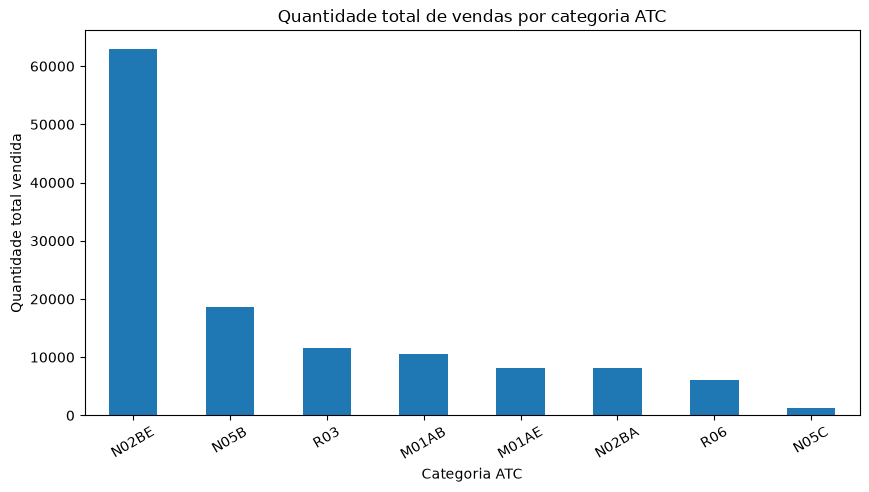

In [246]:
totais.plot(kind="bar", figsize=(10, 5))

plt.title("Quantidade total de vendas por categoria ATC")
plt.xlabel("Categoria ATC")
plt.ylabel("Quantidade total vendida")
plt.xticks(rotation=30)
plt.show()

### Quais foram os três medicamentos com maior volume de vendas em janeiro de 2015, julho de 2016 e setembro de 2017?

In [247]:
monthly = pd.read_csv("data/salesmonthly.csv", parse_dates=["datum"])

categorias_atc = ["M01AB", "M01AE", "N02BA", "N02BE", "N05B", "N05C", "R03", "R06"]

meses_interesse = [
    ("2015-01", "Janeiro de 2015"),
    ("2016-07", "Julho de 2016"),
    ("2017-09", "Setembro de 2017"),
]

resultados = []

for mes, nome_mes in meses_interesse:
    linha_mes = monthly[monthly["datum"].dt.to_period("M") == mes]

    top_3 = (
        linha_mes[categorias_atc]
        .iloc[0]
        .sort_values(ascending=False)
        .head(3)
        .reset_index()
    )

    top_3.columns = ["Codigo ATC", "Total de vendas"]
    top_3["Mes"] = nome_mes
    resultados.append(top_3)

resultado_top_3 = pd.concat(resultados, ignore_index=True)
resultado_top_3["Total de vendas"] = resultado_top_3["Total de vendas"].round(2)

resultado_top_3[["Mes", "Codigo ATC", "Total de vendas"]]


,Mes,Codigo ATC,Total de vendas
0,Janeiro de 2015,N02BE,1044.24
1,Janeiro de 2015,N05B,463.00
2,Janeiro de 2015,R03,177.25
3,Julho de 2016,N02BE,652.36
4,Julho de 2016,N05B,240.00
5,Julho de 2016,M01AB,203.97
6,Setembro de 2017,N02BE,863.75
7,Setembro de 2017,N05B,223.00
8,Setembro de 2017,R03,139.00


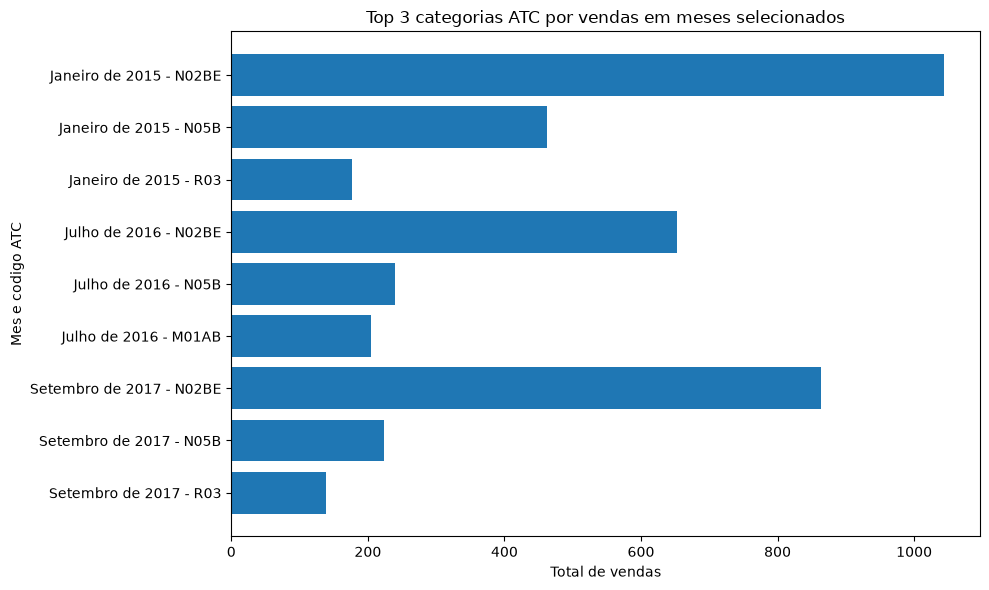

In [248]:
resultado_top_3["Rotulo"] = resultado_top_3["Mes"] + " - " + resultado_top_3["Codigo ATC"]

plt.figure(figsize=(10, 6))
plt.barh(resultado_top_3["Rotulo"], resultado_top_3["Total de vendas"])
plt.title("Top 3 categorias ATC por vendas em meses selecionados")
plt.xlabel("Total de vendas")
plt.ylabel("Mes e codigo ATC")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### Qual foi o medicamento mais vendido em 2017?

In [249]:
monthly = pd.read_csv("data/salesmonthly.csv", parse_dates=["datum"])

categorias_atc = ["M01AB", "M01AE", "N02BA", "N02BE", "N05B", "N05C", "R03", "R06"]

vendas_2017 = monthly[monthly["datum"].dt.year == 2017]

totais_2017 = vendas_2017[categorias_atc].sum().sort_values(ascending=False)

medicamento_mais_vendido_2017 = totais_2017.head(1).reset_index()
medicamento_mais_vendido_2017.columns = ["Codigo ATC", "Total de vendas"]
medicamento_mais_vendido_2017["Total de vendas"] = medicamento_mais_vendido_2017["Total de vendas"].round(2)

medicamento_mais_vendido_2017


,Codigo ATC,Total de vendas
0,N02BE,7674.92


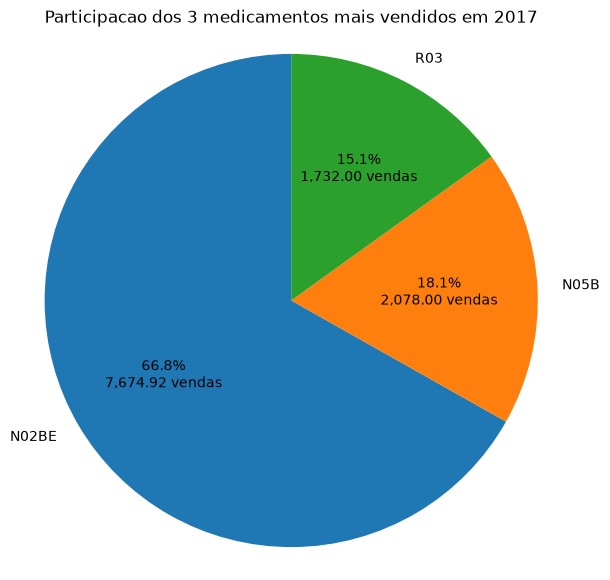

In [250]:
top_3_2017 = totais_2017.head(3)

def formatar_pizza(porcentagem):
    total = top_3_2017.sum()
    valor = porcentagem / 100 * total
    return f"{porcentagem:.1f}%\n{valor:,.2f} vendas"

plt.figure(figsize=(7, 7))
plt.pie(
    top_3_2017.values,
    labels=top_3_2017.index,
    autopct=formatar_pizza,
    startangle=90
)
plt.title("Participacao dos 3 medicamentos mais vendidos em 2017")
plt.axis("equal")
plt.show()


### Qual categoria de medicamentos apresenta a maior media de vendas diarias?

In [251]:
df = pd.read_csv("data/salesdaily.csv", parse_dates=["datum"])

categorias_atc = ["M01AB", "M01AE", "N02BA", "N02BE", "N05B", "N05C", "R03", "R06"]

media_diaria = df[categorias_atc].mean().sort_values(ascending=False)

ranking_media_diaria = media_diaria.reset_index()
ranking_media_diaria.columns = ["Codigo ATC", "Media de vendas diarias"]
ranking_media_diaria["Media de vendas diarias"] = ranking_media_diaria["Media de vendas diarias"].round(2)

ranking_media_diaria


,Codigo ATC,Media de vendas diarias
0,N02BE,29.92
1,N05B,8.85
2,R03,5.51
3,M01AB,5.03
4,M01AE,3.90
5,N02BA,3.88
6,R06,2.90
7,N05C,0.59


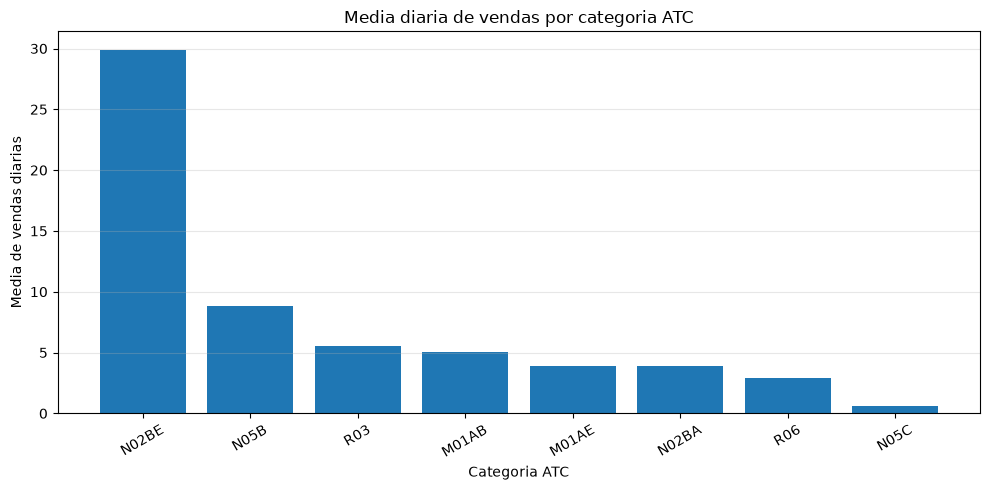

In [252]:
plt.figure(figsize=(10, 5))
plt.bar(media_diaria.index, media_diaria.values)
plt.title("Media diaria de vendas por categoria ATC")
plt.xlabel("Categoria ATC")
plt.ylabel("Media de vendas diarias")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### Os medicamentos respiratorios (R03) sao mais vendidos em determinados meses?

In [253]:
monthly = pd.read_csv("data/salesmonthly.csv", parse_dates=["datum"])

nomes_meses = {
    1: "Janeiro",
    2: "Fevereiro",
    3: "Marco",
    4: "Abril",
    5: "Maio",
    6: "Junho",
    7: "Julho",
    8: "Agosto",
    9: "Setembro",
    10: "Outubro",
    11: "Novembro",
    12: "Dezembro",
}

monthly["Mes"] = monthly["datum"].dt.month

vendas_r03_por_mes = (
    monthly.groupby("Mes")["R03"]
    .mean()
    .reset_index()
    .sort_values("Mes")
)

vendas_r03_por_mes["Nome do mes"] = vendas_r03_por_mes["Mes"].map(nomes_meses)
vendas_r03_por_mes["Media de vendas R03"] = vendas_r03_por_mes["R03"].round(2)

vendas_r03_por_mes[["Mes", "Nome do mes", "Media de vendas R03"]]

,Mes,Nome do mes,Media de vendas R03
0,1,Janeiro,178.04
1,2,Fevereiro,195.17
2,3,Marco,204.17
3,4,Abril,184.50
4,5,Maio,163.33
5,6,Junho,130.50
6,7,Julho,91.67
7,8,Agosto,96.17
8,9,Setembro,138.67
9,10,Outubro,203.83


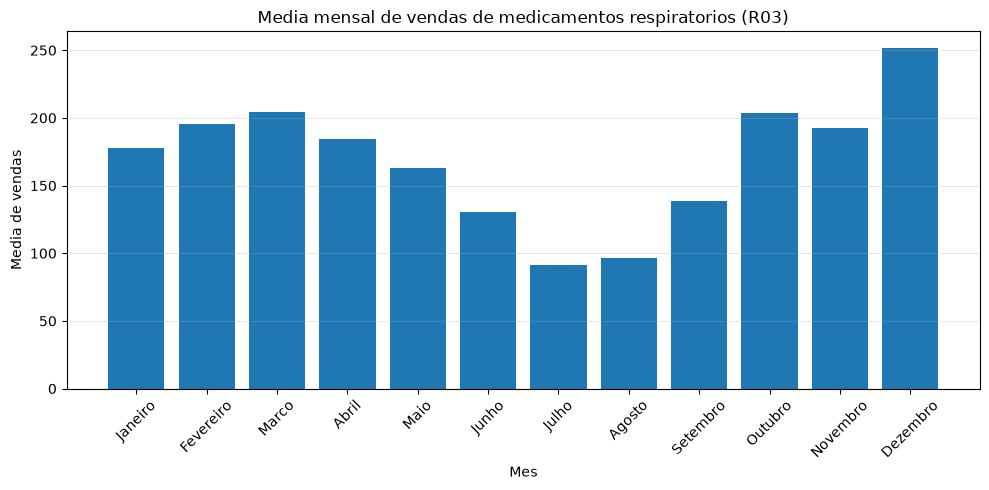

In [254]:
plt.figure(figsize=(10, 5))
plt.bar(vendas_r03_por_mes["Nome do mes"], vendas_r03_por_mes["Media de vendas R03"])
plt.title("Media mensal de vendas de medicamentos respiratorios (R03)")
plt.xlabel("Mes")
plt.ylabel("Media de vendas")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()